In [1]:
import warnings
warnings.filterwarnings("ignore", message="overflow encountered")
warnings.filterwarnings("ignore", message="divide by zero encountered")
warnings.filterwarnings("ignore", message="invalid value encountered in")
warnings.filterwarnings(
    "ignore",
    message="The default of observed=False is deprecated"
)
warnings.filterwarnings("ignore", message="overflow encountered in reduce")

import numpy as np
import pandas as pd
import random
import math

from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries imported. Warnings suppressed.")

Libraries imported. Warnings suppressed.


In [2]:
df = pd.read_pickle("train_df_sample.pkl")
print("Data shape:", df.shape)
df.head(5)


Data shape: (100000, 919)


,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,D_39_last,...,D_64_count,D_64_last,D_64_nunique,D_66_count,D_66_last,D_66_nunique,D_68_count,D_68_last,D_68_nunique,target
customer_ID,,,,,,,,,,,,,,,,,,,,,
f9e9fbdc82859e7fdcea35523a78f466aa40d1bb7158da9eb6f80f5f3e7b2c49,0.419922,0.033698,0.390381,0.449951,0.390869,0.336670,0.383050,0.000727,0.680176,0.680176,...,1,U,1,1,1.0,1,1,5.0,1,1
824526e632f8f6c497b71cb13ec0a519be76344d47297097c49afd0ac8d0ab01,0.603516,0.033983,0.542480,0.651367,0.613281,0.284424,0.238159,0.004951,0.801758,0.302979,...,13,U,1,0,NaN,0,13,6.0,1,0
b73f63bcbb43055d5bc1b0c4365efa407a939455387a253ea3f1101eb9bea8d3,0.823730,NaN,0.823730,0.823730,0.823730,0.000104,NaN,0.000104,0.000104,0.000104,...,0,NaN,0,0,NaN,0,0,NaN,0,0
783d9b5d9f6594d1a5a42d8474d328b72e8f2a5adc0a6004ba2874c72c3ecfef,0.925293,0.070185,0.702637,0.964844,0.957031,0.136353,0.149279,0.000043,0.389404,0.241455,...,13,O,1,13,1.0,1,13,6.0,1,0
2f6a347c73f2fd188d6e110f04275bacb5e0550d7d9d6c3939e8b0ee42469fa2,0.864258,0.017011,0.826172,0.890625,0.826172,0.105286,0.137151,0.004486,0.324707,0.215454,...,13,R,1,0,NaN,0,13,6.0,1,0


In [3]:
def summary(df):
    summ = pd.DataFrame(df.dtypes, columns=['data type'])
    summ['#missing'] = df.isnull().sum().values
    summ['%missing'] = (df.isnull().sum().values / len(df)) * 100
    summ['#unique'] = df.nunique().values

    desc = df.describe(include='all').transpose()
    if 'min' in desc.columns:
        summ['min'] = desc['min'].values
    else:
        summ['min'] = np.nan

    if 'max' in desc.columns:
        summ['max'] = desc['max'].values
    else:
        summ['max'] = np.nan

    if len(df) > 0:
        summ['first value'] = df.iloc[0].values
    if len(df) > 1:
        summ['second value'] = df.iloc[1].values
    if len(df) > 2:
        summ['third value'] = df.iloc[2].values

    return summ

print("Initial data shape:", df.shape)
summary_df = summary(df)
display(summary_df.head(10))

Initial data shape: (100000, 919)


,data type,#missing,%missing,#unique,min,max,first value,second value,third value
P_2_mean,float16,512,0.512,4537,-0.338379,1.009766,0.419922,0.603516,0.82373
P_2_std,float64,1686,1.686,96920,0.0,0.439728,0.033698,0.033983,NaN
P_2_min,float16,512,0.512,7525,-0.458984,1.009766,0.390381,0.54248,0.82373
P_2_max,float16,512,0.512,3226,-0.338379,1.009766,0.449951,0.651367,0.82373
P_2_last,float16,512,0.512,6593,-0.458984,1.009766,0.390869,0.613281,0.82373
D_39_mean,float16,0,0.000,8990,0.000005,4.445312,0.33667,0.284424,0.000104
D_39_std,float64,1110,1.110,98836,0.0,2.544629,0.38305,0.238159,NaN
D_39_min,float16,0,0.000,9850,0.0,4.441406,0.000727,0.004951,0.000104
D_39_max,float16,0,0.000,4004,0.000005,5.390625,0.680176,0.801758,0.000104
D_39_last,float16,0,0.000,8520,0.0,5.0,0.680176,0.302979,0.000104


In [4]:
def drop_null_cols(df, threshold=0.8):
    null_percent = df.isnull().mean()
    drop_cols = list(null_percent[null_percent > threshold].index)
    df = df.drop(drop_cols, axis=1)
    print(f"Dropped {len(drop_cols)} columns (>{threshold*100}% missing).")
    return df

df = drop_null_cols(df, 0.8)
print("After dropping high-missing columns:", df.shape)


Dropped 106 columns (>80.0% missing).
After dropping high-missing columns: (100000, 813)


In [5]:
cat_features = [
    "B_30", "B_38", "D_114", "D_116", "D_117",
    "D_120", "D_126", "D_63", "D_64", "D_68"
]
cat_features = [
    f"{cf}_last" for cf in cat_features
]

cat_features = [c for c in cat_features if c in df.columns]

for c in cat_features:
    df[c] = df[c].astype(str)

le_encoder = LabelEncoder()
for c in cat_features:
    df[c] = df[c].replace("nan", "NaN")
    df[c] = le_encoder.fit_transform(df[c])

In [6]:
target_col = "target"
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols = [col for col in numeric_cols
                if col not in cat_features and col != target_col]

# Added in the repo (not in printed listing 5.6): random.sample() is unseeded in the
# book, so the 100-column sample (and the 4 columns drawn in listing 5.9) changed on
# every run. Seeding makes the whole notebook reproducible.
random.seed(2023)
num_cols_sample = random.sample(
    numeric_cols,
    min(100, len(numeric_cols))
)
imputer = SimpleImputer(strategy='mean')
df[num_cols_sample] = imputer.fit_transform(df[num_cols_sample])

In [7]:
fig2 = px.pie(
    df,
    names='target',
    height=400,
    width=600,
    hole=0.7,
    title='target class Overview',
    color_discrete_sequence=['#4c78a8', '#72b7b2']
)
fig2.update_traces(
    hovertemplate=None,
    textposition='outside',
    textinfo='percent+label',
    rotation=0
)
fig2.update_layout(
    margin=dict(t=100, b=30, l=0, r=0),
    showlegend=False,
    plot_bgcolor='#fafafa',
    paper_bgcolor='#fafafa',
    title_font=dict(size=20, color='#555', family="Lato, sans-serif"),
    font=dict(size=17, color='#8a8d93'),
    hoverlabel=dict(
    bgcolor="#444",
    font_size=13,
    font_family="Lato, sans-serif"
)
)
fig2.show()

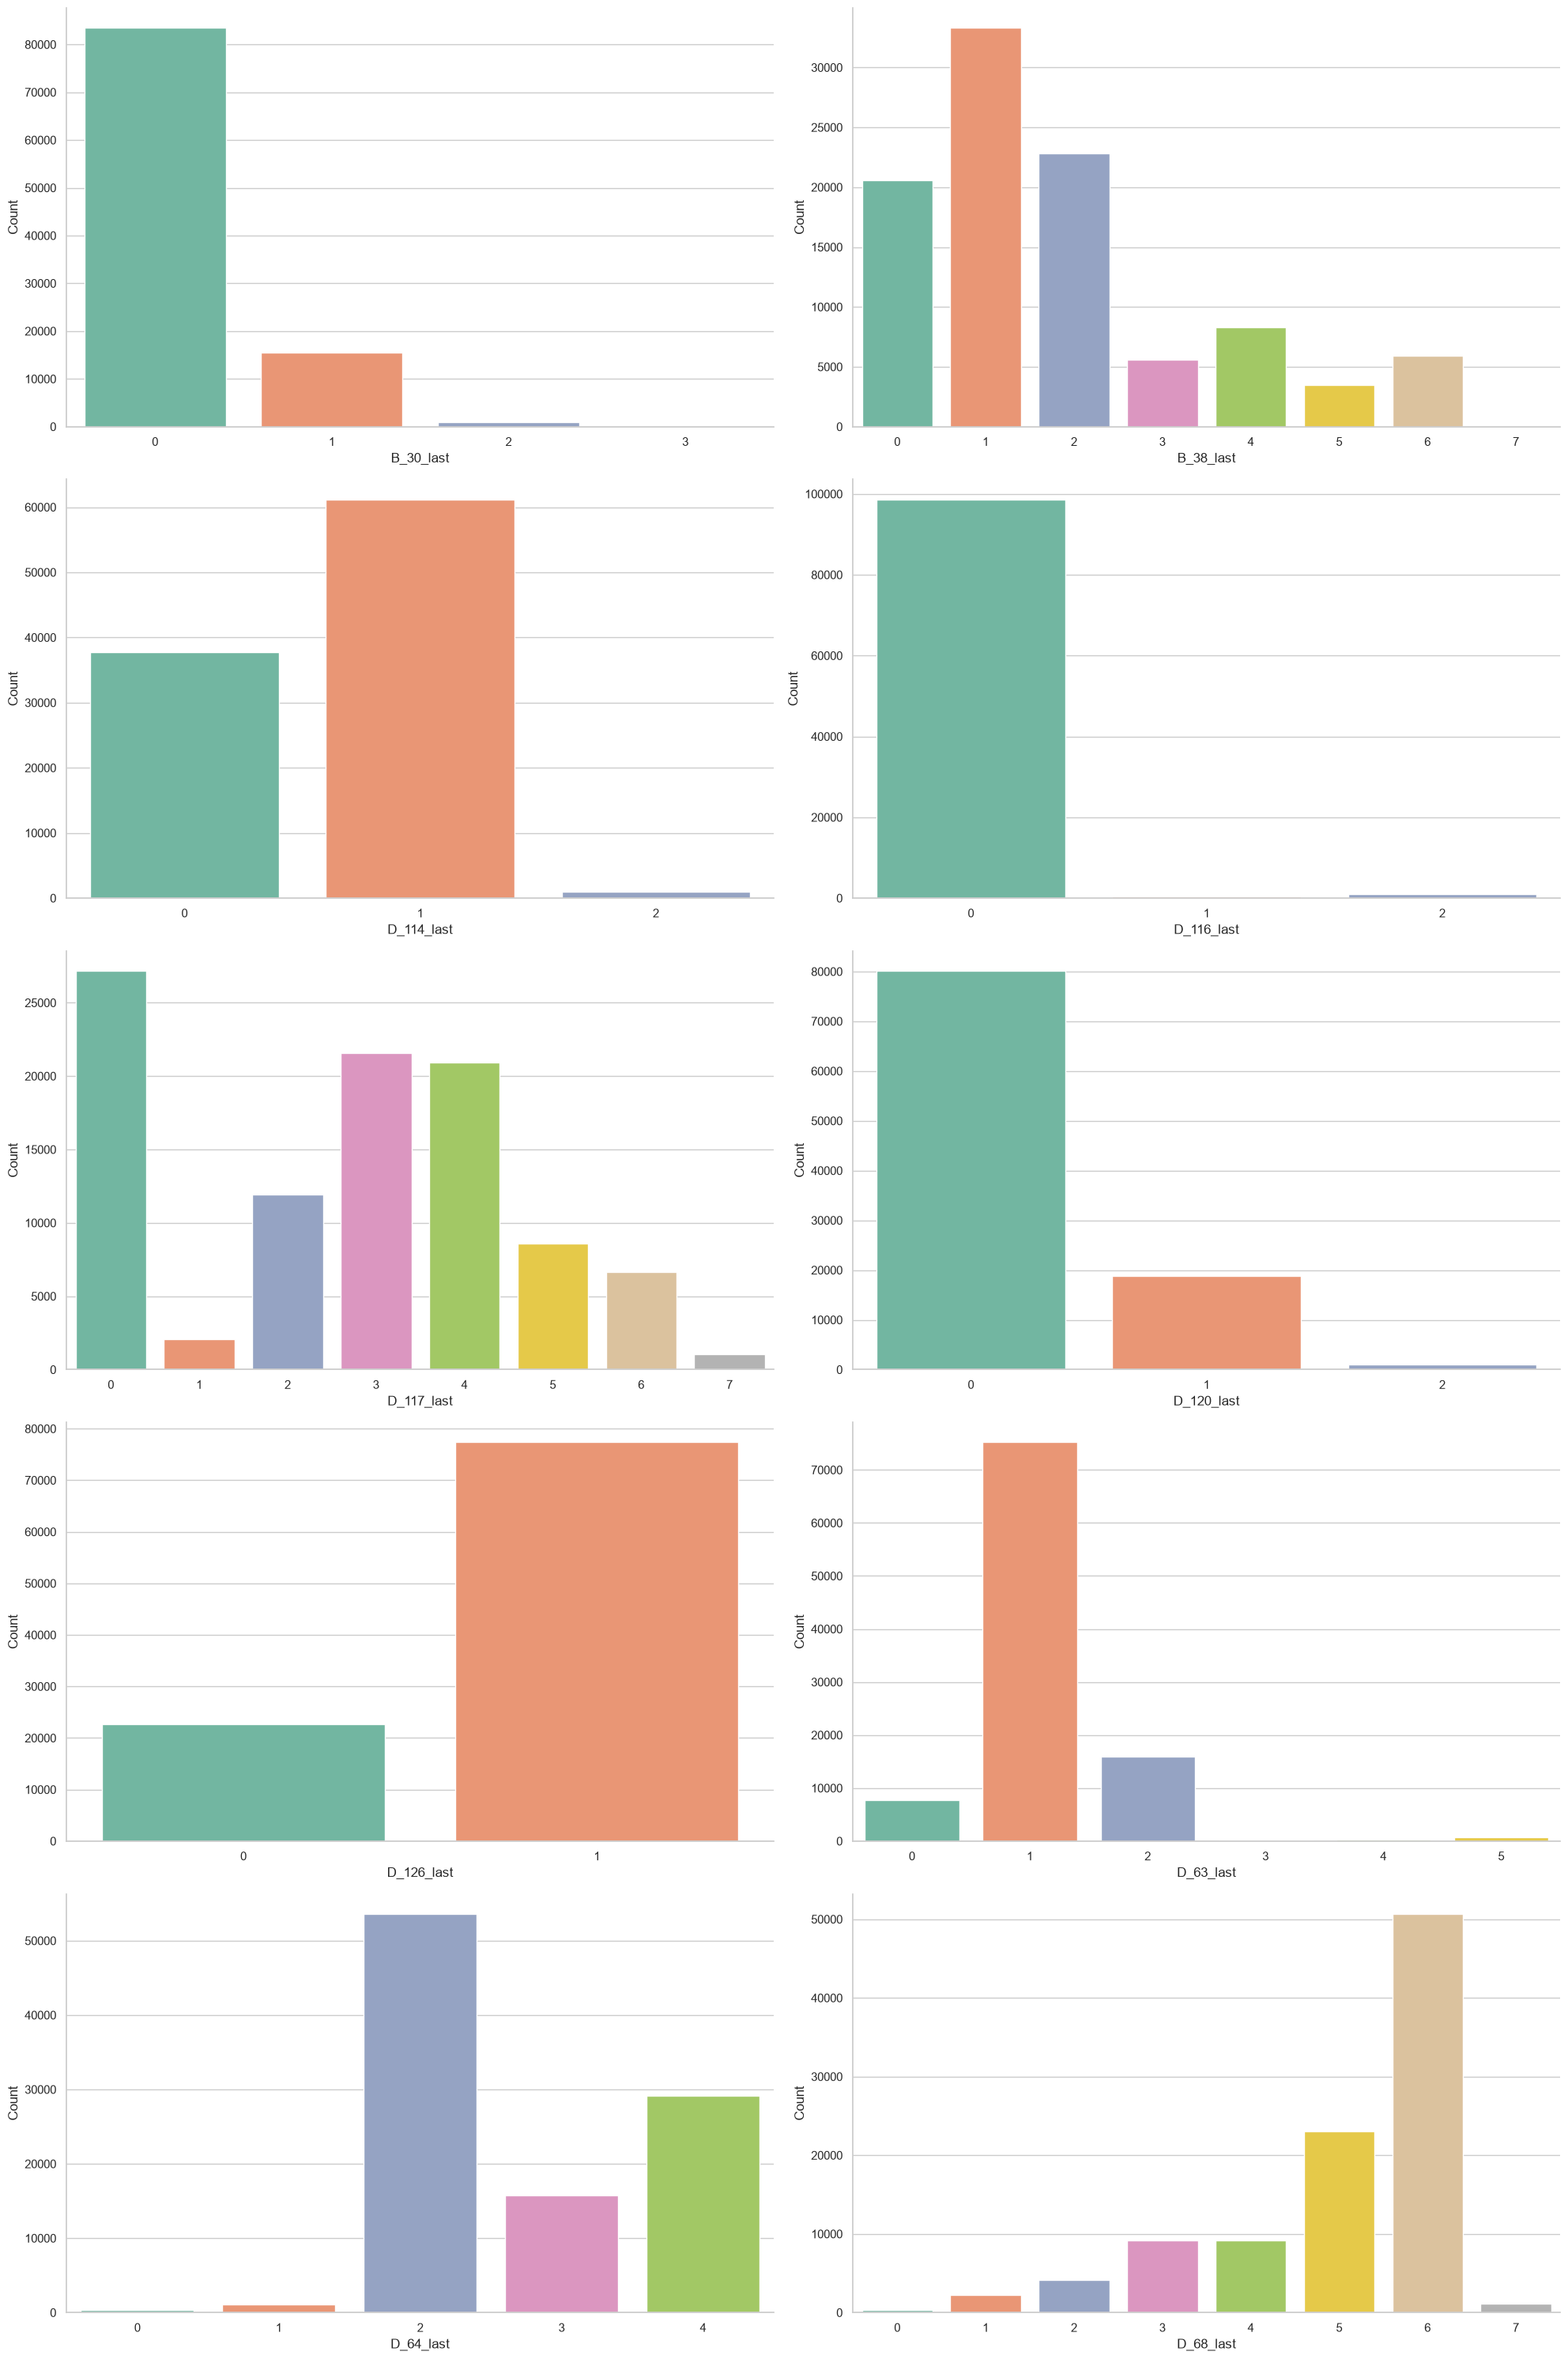

In [8]:
sns.set(style="whitegrid")

fig, axs = plt.subplots(math.ceil(len(cat_features)/2), 2, figsize=(20, 30))

for i, feature in enumerate(cat_features):
    row = i // 2
    col = i % 2
    cat_counts = df[feature].value_counts()
    sns.barplot(
        x=cat_counts.index,
        y=cat_counts.values,
        palette="Set2",
        ax=axs[row, col]
    )
    axs[row, col].set_xlabel(feature)
    axs[row, col].set_ylabel("Count")
    sns.despine(ax=axs[row, col])

plt.tight_layout()
plt.show()

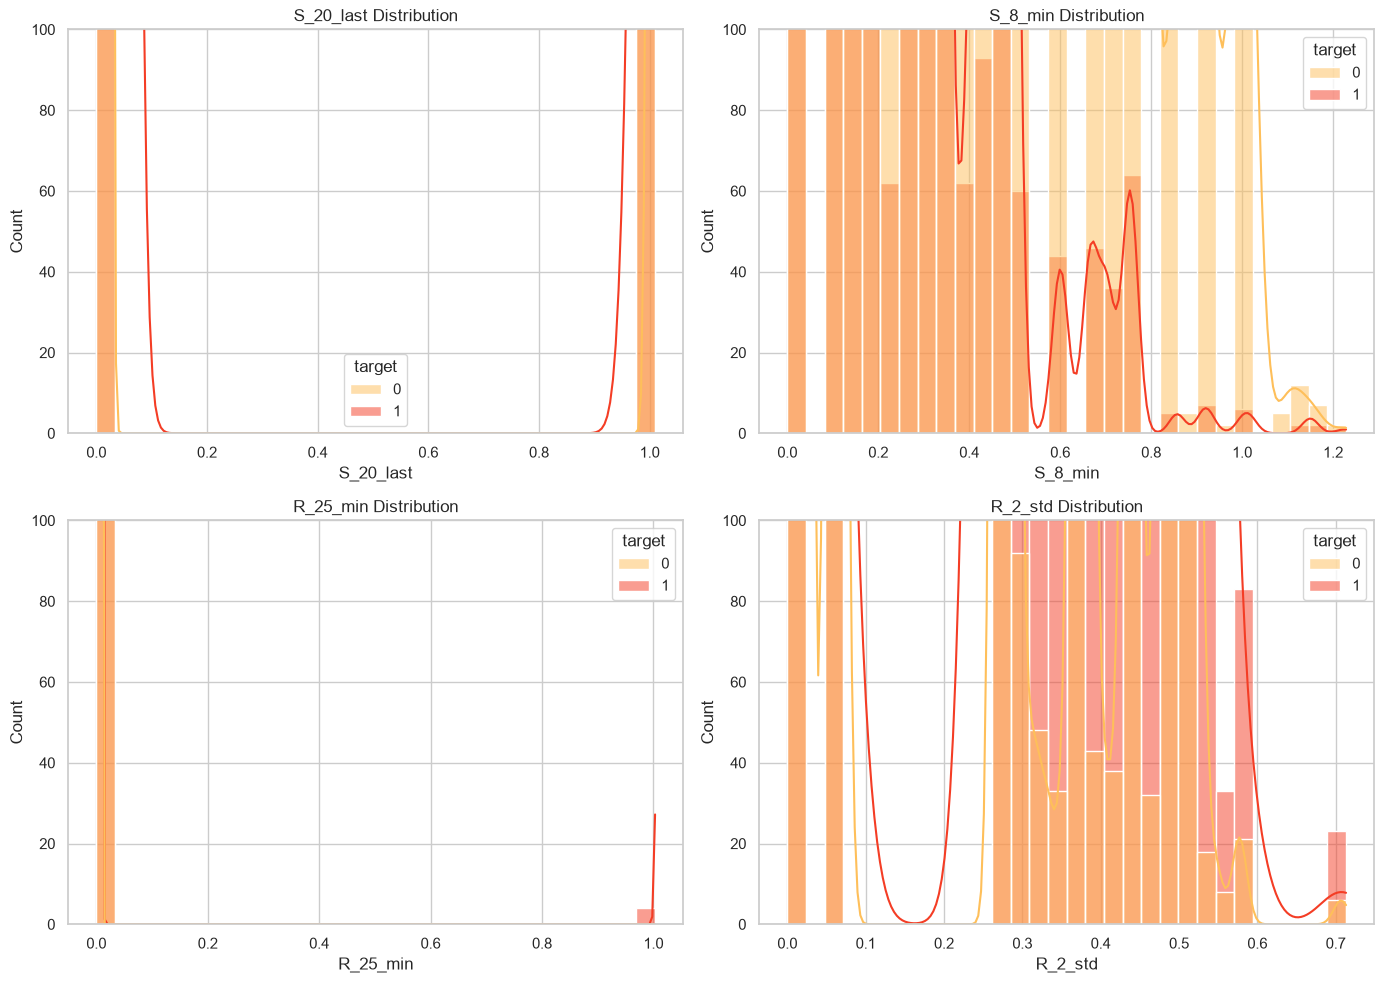

In [9]:
exp_cols = random.sample(
    num_cols_sample, k=4
)

plt.figure(
    figsize=(14, 10)
)

for idx, column in enumerate(exp_cols):
    plt.subplot(2, 2, idx + 1)
    sns.histplot(
        data=df,
        x=column,
        hue="target",
        bins=30,
        kde=True,
        palette='YlOrRd'
    )
    plt.title(f"{column} Distribution")
    plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [10]:
def calculate_woe_iv(df, feature_list, cat_features, target="target", iv_threshold=0.02):
    import numpy as np
    import pandas as pd

    epsilon = 0.5  # avoid infinite logs when event_rate or non_event_rate is zero
    max_woe = 10   # clamp extreme WOE for numeric stability

    result_df = pd.DataFrame(columns=['Feature','Bin','WOE','IV','IV_sum'])
    selected_features = []
    bin_edges_dict = {}
    woe_dict = {}

    for feat in feature_list:
        temp = df[[feat, target]].copy()

        # A) For categorical features
        if feat in cat_features:
            grouped = temp.groupby(feat)[target].agg([
                ('count_non_event', lambda x: (1 - x).sum()),
                ('count_event', lambda x: x.sum())
            ]).reset_index()

            total_non_event = grouped['count_non_event'].sum()
            total_event = grouped['count_event'].sum()

            # Smooth both sides by epsilon
            grouped['event_rate']     = (grouped['count_event'] + epsilon) / (total_event + 2*epsilon)
            grouped['non_event_rate'] = (grouped['count_non_event'] + epsilon) / (total_non_event + 2*epsilon)

            grouped['WOE'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
            grouped['WOE'] = grouped['WOE'].clip(-max_woe, max_woe)

            grouped['IV'] = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['WOE']
            iv_sum = grouped['IV'].sum()

            if iv_sum >= iv_threshold:
                selected_features.append(feat)

            bin_edges_dict[feat] = grouped[feat].tolist()
            woe_dict[feat] = dict(zip(grouped[feat], grouped['WOE']))

            for _, row in grouped.iterrows():
                row_data = {
                    'Feature': feat,
                    'Bin': row[feat],
                    'WOE': row['WOE'],
                    'IV': row['IV'],
                    'IV_sum': iv_sum
                }
                result_df = pd.concat([result_df, pd.DataFrame([row_data])], ignore_index=True)

        # B) For numeric features
        else:
            temp[feat] = temp[feat].fillna(temp[feat].median())
            try:
                temp[feat + '_bins'], bins = pd.qcut(temp[feat], 10, duplicates='drop', retbins=True)
            except ValueError:
                continue

            bin_edges_dict[feat] = bins
            grouped = temp.groupby(feat + '_bins')[target].agg([
                ('count_non_event', lambda x: (1 - x).sum()),
                ('count_event', lambda x: x.sum())
            ]).reset_index()

            total_non_event = grouped['count_non_event'].sum()
            total_event = grouped['count_event'].sum()

            grouped['event_rate']     = (grouped['count_event'] + epsilon) / (total_event + 2*epsilon)
            grouped['non_event_rate'] = (grouped['count_non_event'] + epsilon) / (total_non_event + 2*epsilon)

            grouped['WOE'] = np.log(grouped['event_rate'] / grouped['non_event_rate'])
            grouped['WOE'] = grouped['WOE'].clip(-max_woe, max_woe)
            grouped['IV']  = (grouped['event_rate'] - grouped['non_event_rate']) * grouped['WOE']
            iv_sum = grouped['IV'].sum()

            if iv_sum >= iv_threshold:
                selected_features.append(feat)

            feat_woe_map = {}
            for _, row in grouped.iterrows():
                bin_label = str(row[feat + '_bins'])
                feat_woe_map[bin_label] = row['WOE']

                row_data = {
                    'Feature': feat,
                    'Bin': bin_label,
                    'WOE': row['WOE'],
                    'IV': row['IV'],
                    'IV_sum': iv_sum
                }
                result_df = pd.concat([result_df, pd.DataFrame([row_data])], ignore_index=True)

            woe_dict[feat] = feat_woe_map

    return result_df, selected_features, bin_edges_dict, woe_dict

In [11]:
feature_list = num_cols_sample + cat_features
if target_col in feature_list:
    feature_list.remove(target_col)

woe_result, selected_feats, bin_edges, woe_maps = calculate_woe_iv(
    df, feature_list, cat_features, target=target_col, iv_threshold=0.02
)
print("Total features in feature_list:", len(feature_list))
print("Selected features (IV>=0.02):", len(selected_feats), selected_feats)
display(woe_result.head(10))


Total features in feature_list: 110
Selected features (IV>=0.02): 88 ['S_16_min', 'D_128_max', 'S_15_min', 'D_107_mean', 'S_22_last', 'D_75_mean', 'B_8_min', 'D_52_std', 'D_113_std', 'D_70_mean', 'D_127_max', 'D_131_mean', 'B_22_max', 'S_8_min', 'S_8_mean', 'D_112_min', 'B_2_min', 'B_14_mean', 'B_26_std', 'R_2_std', 'B_37_max', 'D_52_last', 'B_3_last', 'R_5_last', 'S_6_max', 'D_75_last', 'B_5_min', 'D_46_min', 'D_92_mean', 'S_20_mean', 'D_41_std', 'D_52_mean', 'S_23_std', 'S_11_min', 'B_30_count', 'D_131_min', 'D_50_last', 'S_24_last', 'D_46_mean', 'R_2_mean', 'D_53_max', 'D_143_last', 'S_27_std', 'D_58_max', 'D_104_min', 'D_55_std', 'D_91_mean', 'B_14_std', 'B_21_min', 'B_20_std', 'D_130_last', 'R_3_std', 'S_23_last', 'B_4_min', 'D_79_max', 'S_6_min', 'D_69_std', 'D_48_last', 'R_20_std', 'D_81_mean', 'D_130_max', 'D_123_mean', 'D_72_std', 'S_12_min', 'S_15_std', 'S_13_mean', 'B_10_max', 'D_46_last', 'B_25_mean', 'D_61_min', 'S_5_max', 'R_21_min', 'R_7_mean', 'R_25_mean', 'S_27_min', '

,Feature,Bin,WOE,IV,IV_sum
0,S_16_min,"(-0.001, 9.01e-05]",-0.096962,0.000918,0.024468
1,S_16_min,"(9.01e-05, 0.00019]",-0.104448,0.001064,0.024468
2,S_16_min,"(0.00019, 0.000302]",-0.075157,0.000555,0.024468
3,S_16_min,"(0.000302, 0.000432]",-0.064299,0.000407,0.024468
4,S_16_min,"(0.000432, 0.000584]",-0.029580,0.000087,0.024468
5,S_16_min,"(0.000584, 0.00077]",-0.067262,0.000444,0.024468
6,S_16_min,"(0.00077, 0.00102]",-0.063618,0.000399,0.024468
7,S_16_min,"(0.00102, 0.00137]",-0.040853,0.000165,0.024468
8,S_16_min,"(0.00137, 0.00204]",0.064316,0.000420,0.024468
9,S_16_min,"(0.00204, 16.359]",0.427491,0.020009,0.024468


In [12]:
def transform_to_woe(
    df,
    selected_features,
    cat_features,
    bin_edges_dict,
    woe_dict,
    target="target"
):
    df_woe = df[selected_features + [target]].copy()
    for feat in selected_features:
        if feat in cat_features:
            df_woe[feat] = df_woe[feat].map(woe_dict[feat])
        else:
            bins = bin_edges_dict[feat]
            df_woe[feat] = pd.cut(
                df_woe[feat],
                bins=bins,
                include_lowest=True
            ).astype(str)
            df_woe[feat] = df_woe[feat].map(woe_dict[feat])
    return df_woe

df_woe = transform_to_woe(
    df,
    selected_feats,
    cat_features,
    bin_edges,
    woe_maps,
    target=target_col
)
print("df_woe shape:", df_woe.shape)
df_woe.head(5)

df_woe shape: (100000, 89)


,S_16_min,D_128_max,S_15_min,D_107_mean,S_22_last,D_75_mean,B_8_min,D_52_std,D_113_std,D_70_mean,...,P_2_std,B_30_last,B_38_last,D_114_last,D_117_last,D_120_last,D_63_last,D_64_last,D_68_last,target
customer_ID,,,,,,,,,,,,,,,,,,,,,
f9e9fbdc82859e7fdcea35523a78f466aa40d1bb7158da9eb6f80f5f3e7b2c49,-0.040853,0.586747,-0.180554,0.007715,1.318260,0.066911,0.794457,-0.201034,0.159487,-0.701085,...,-0.466908,-0.469072,1.408671,0.508503,0.192835,0.956734,0.064489,0.489746,0.110172,1
824526e632f8f6c497b71cb13ec0a519be76344d47297097c49afd0ac8d0ab01,-0.040853,-0.519436,-0.245382,-0.316081,0.943743,-0.587104,-0.919898,-0.081237,-0.144364,-0.321478,...,-0.466908,-0.469072,0.394107,0.508503,-0.421856,-0.291746,0.249567,0.489746,-0.451153,0
b73f63bcbb43055d5bc1b0c4365efa407a939455387a253ea3f1101eb9bea8d3,0.427491,-0.143095,-0.442272,0.007715,0.943743,-2.892530,0.513223,0.188110,0.159487,0.137011,...,0.083184,-0.469072,-1.277385,0.371938,0.371938,0.371938,0.064489,0.360432,0.339535,0
783d9b5d9f6594d1a5a42d8474d328b72e8f2a5adc0a6004ba2874c72c3ecfef,-0.029580,-0.511863,-0.681914,-0.274031,-0.343514,-2.817832,-0.914572,-0.201034,0.159487,-0.963072,...,0.448887,-0.469072,-1.873338,-0.393664,-0.751398,-0.291746,0.064489,-0.474460,-0.451153,0
2f6a347c73f2fd188d6e110f04275bacb5e0550d7d9d6c3939e8b0ee42469fa2,0.064316,-0.511863,-0.681914,-0.274031,0.138614,-2.727361,-0.945336,-0.141019,-0.192421,-0.941745,...,-0.983682,-0.469072,-1.873338,-0.393664,0.192835,-0.291746,0.249567,0.371108,-0.451153,0


In [13]:
def xgboost_model(df_woe, target="target", folds=5, seed=2023):
    import numpy as np
    from sklearn.model_selection import StratifiedKFold
    from xgboost import XGBClassifier
    from sklearn.metrics import roc_auc_score

    xgb_models = []
    xgb_oof = []
    predictions = np.zeros(len(df_woe), dtype=float)
    f_imp = []

    X = df_woe.drop(columns=[target])
    y = df_woe[target]

    skf = StratifiedKFold(n_splits=folds, shuffle=True, random_state=seed)

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n{'#'*24} Training FOLD {fold_idx+1} {'#'*24}")

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBClassifier(
            n_estimators=1000,
            max_depth=4,
            learning_rate=0.2,
            colsample_bytree=0.67,
            n_jobs=-1,
            random_state=seed
        )

        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=0)
        val_preds = model.predict_proba(X_val)[:, 1]
        val_score = roc_auc_score(y_val, val_preds)

        oof_array = np.vstack([val_idx, val_preds, y_val]).T
        xgb_oof.append(oof_array)

        feat_imp = dict(
        zip(X_train.columns, model.feature_importances_)
        )
        f_imp.append(feat_imp)

        print(f"{' '*16}Fold {fold_idx+1} AUC = {val_score:.5f}")
        xgb_models.append(model)

        if val_score > 0.917:
            full_probs = model.predict_proba(X)[:, 1]
            predictions += full_probs

    predictions /= folds

    fold_aucs = []
    for arr in xgb_oof:
        fold_auc = roc_auc_score(arr[:, 2], arr[:, 1])
        fold_aucs.append(fold_auc)
    mean_auc = np.mean(fold_aucs)

    print("\n" + "*"*45)
    print(f"Mean AUC: {mean_auc:.5f}")

    return xgb_models, xgb_oof, predictions, f_imp

In [14]:
xgb_models, xgb_oof, predictions, f_imp = xgboost_model(
    df_woe,
    target="target",
    folds=5,
    seed=2023
)



######################## Training FOLD 1 ########################


                Fold 1 AUC = 0.94625

######################## Training FOLD 2 ########################


                Fold 2 AUC = 0.94722

######################## Training FOLD 3 ########################


                Fold 3 AUC = 0.94786

######################## Training FOLD 4 ########################


                Fold 4 AUC = 0.94711

######################## Training FOLD 5 ########################


                Fold 5 AUC = 0.94658

*********************************************
Mean AUC: 0.94701


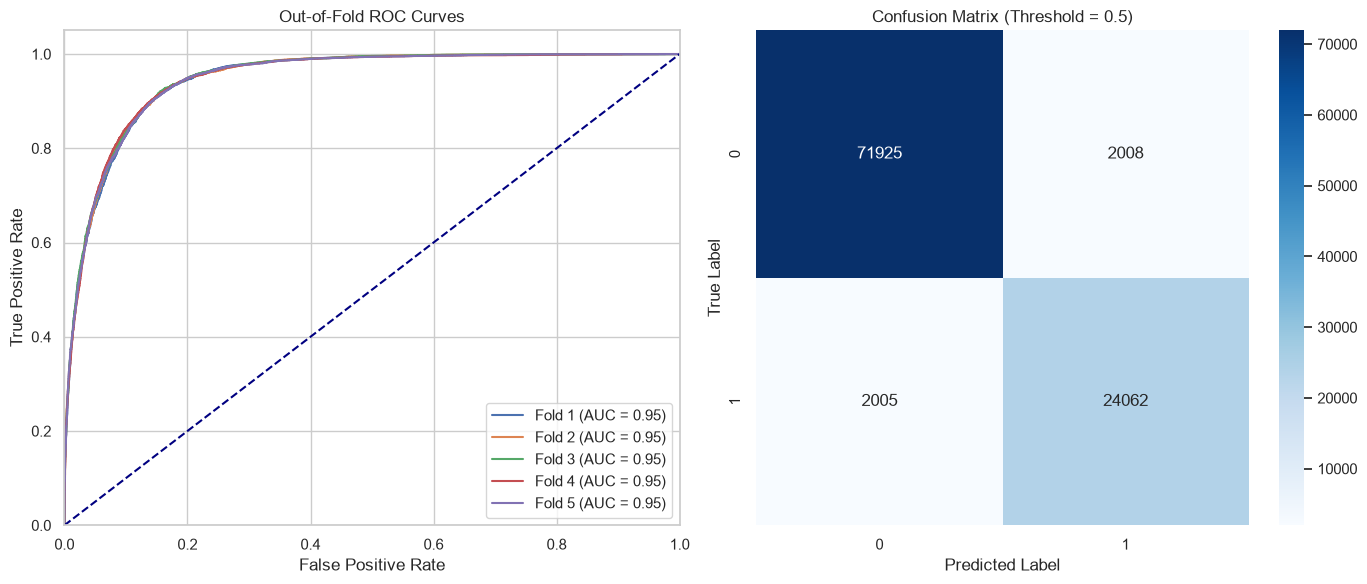

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

plt.figure(figsize=(14, 6))

# 1) Plot ROC curves for each fold's OOF predictions
plt.subplot(1, 2, 1)
for idx, oof in enumerate(xgb_oof):
    fpr, tpr, _ = roc_curve(oof[:, 2], oof[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Fold {idx+1} (AUC = {roc_auc:.2f})')

plt.plot(
    [0, 1], [0, 1],
    color='navy',
    linestyle='--'
)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Out-of-Fold ROC Curves')
plt.legend(loc="lower right")

# 2) Compute and plot confusion matrix on final predictions
plt.subplot(1, 2, 2)

predictions_class = [
    1 if p > 0.5 else 0 for p in predictions
]

cm = confusion_matrix(
    df_woe['target'], predictions_class
)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Threshold = 0.5)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

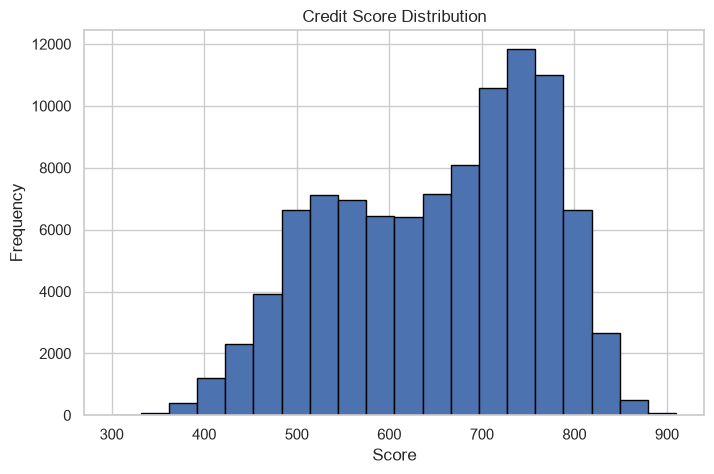

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt

base_score = 650
PDO = 20
factor = PDO / np.log(2)
offset = base_score - (factor * np.log(20))

def calculate_score(prob_default, factor, offset):
    prob_default = np.clip(prob_default, 1e-6, 1 - 1e-6)
    odds = prob_default / (1 - prob_default)
    raw_score = offset - factor * np.log(odds)
    return np.clip(raw_score, 250, 1000)

scores = calculate_score(predictions, factor, offset)
scores = np.round(scores)

plt.figure(figsize=(8, 5))
plt.hist(scores, bins=20, edgecolor='black')
plt.title('Credit Score Distribution')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

In [17]:
X_final = df_woe.drop(columns=["target"])
y_final = df_woe["target"]

from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.2,
    n_jobs=-1,
    random_state=2023
)

final_model.fit(X_final, y_final)
print("Final model trained on the full WOE-coded dataset.")


Final model trained on the full WOE-coded dataset.


In [18]:
base_score = 650
PDO = 20
factor = PDO / math.log(2)
offset = base_score - (factor * math.log(20))

def single_inference_bfsi(model, row, factor, offset):
    if len(row.shape) == 1:
        row = row.values.reshape(1, -1)

    prob_default = model.predict_proba(row)[:, 1][0]
    prob_default = float(np.clip(prob_default, 1e-6, 1 - 1e-6))
    odds = prob_default / (1 - prob_default)
    raw_score = offset - factor * math.log(odds)
    credit_score = np.clip(raw_score, 250, 1000)
    return prob_default, round(credit_score)

sample_row = X_final.iloc[0]
p_def, c_score = single_inference_bfsi(final_model, sample_row, factor, offset)
print(f"Probability of default = {p_def:.4f}, BFSI credit score = {c_score}")

Probability of default = 0.8500, BFSI credit score = 514
